# Informe — Pipeline ETL de presuntos suicidios en Colombia, 2015-2024

**Avance 2 · ETL · Universidad Autónoma de Occidente**
Ana María Toro · Ana Sofía Perhueza · Daniel Gómez Sermeño · Daniel Steven Colmenares

Este informe presenta los **OKR y KPI medidos por el pipeline** y responde las preguntas de negocio en tres niveles: **nacional → Valle del Cauca → municipios del Valle**. Todas las cifras se calculan aquí a partir de las tablas de la capa **gold**; ninguna está escrita a mano.

Para ejecutarlo: primero `python main.py` (genera `data/gold/`), luego este notebook.

| Tabla gold | Contenido | Acceso |
|---|---|---|
| `gold_tasa_mortalidad` | Tasa de mortalidad por presunto suicidio por 100.000 hab. (nacional, departamental, municipios foco; anual, quinquenal y decenal; por sexo y grupo de edad) | Tablero |
| `gold_agregado_tablero` | Conteos agregados con supresión de celdas de menos de 5 casos | Tablero |
| `gold_kpi_calidad` | KR y KPI medidos en cada ejecución | Tablero |
| `dim_departamento`, `dim_municipio`, `dim_grupo_edad` | Tablas maestras: llave de cruce con el DANE | Tablero |
| `gold_suicidios` | Detalle por caso, minimizado | Solo analistas |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src.utils import load_config, project_path

config = load_config()
GOLD = project_path(config["paths"]["gold_dir"])
U = config["thresholds"]
FOCO = config["scope"]["departamento_foco"]
K = U["privacidad_min_casos"]

leer = lambda n: pd.read_csv(GOLD / f"{n}.csv", dtype={"codigo": str, "codigo_dane": str, "codigo_municipio": str,
                                                      "codigo_dane_departamento": str, "codigo_dane_municipio": str})
tasas, tablero, kpis = leer("gold_tasa_mortalidad"), leer("gold_agregado_tablero"), leer("gold_kpi_calidad")
casos, dim_dep, dim_mun = leer("gold_suicidios"), leer("dim_departamento"), leer("dim_municipio")

pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)
fmt = lambda x: f"{x:,.0f}".replace(",", ".")

# Estilo de graficos: marcas finas, grilla tenue, una sola escala por grafico
AZUL, NARANJA, AQUA, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
plt.rcParams.update({"figure.figsize": (10, 4.2), "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#b5b4ad",
                     "axes.grid": True, "grid.color": "#e4e3dd", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
                     "xtick.color": "#52514e", "ytick.color": "#52514e", "lines.linewidth": 2,
                     "legend.frameon": False})

def tasa(nivel=None, codigo=None, tipo="anual", sexo="Total", grupo="Total"):
    t = tasas[(tasas["tipo_periodo"] == tipo) & (tasas["sexo"] == sexo) & (tasas["grupo_edad"] == grupo)]
    if nivel: t = t[t["nivel"] == nivel]
    if codigo: t = t[t["codigo"] == codigo]
    return t

## 1. Respuesta a la retroalimentación del Avance 1

| Comentario del profesor | Qué se hizo | Dónde |
|---|---|---|
| KR de 100 % de carga y 100 % de limpieza son demasiado absolutos | Se separa lo que es **proceso** (ningún registro se pierde sin explicación: debe cumplirse siempre) de lo que es **dato** (umbrales: ≥ 99,5 % válidos, ≥ 99 % de códigos que cruzan). Los registros inválidos se **rechazan y se documentan**, no se fuerzan | Sección 2; `src/transform/validate.py`; `data/silver/rechazados_suicidios.csv` |
| "Tasa de incidencia" no es el término correcto para defunciones | Se usa **tasa de mortalidad por presunto suicidio** (casos de presunto suicidio / población proyectada × 100.000). Se dice "presunto" porque es la clasificación forense de Medicina Legal | Secciones 5 y 6 |
| Documentar la llave de cruce con el DANE (año, municipio, sexo, grupo de edad) | Tablas maestras `dim_departamento`, `dim_municipio` y `dim_grupo_edad`. Se agregan las proyecciones DANE **por sexo y edad simple** (departamental) y **municipales** | Sección 5.1 |
| Variables sensibles: agregación, minimización y control de acceso | 10 variables sensibles que no se usan quedan **fuera de gold**; el tablero solo recibe **agregados con supresión < 5 casos**; en PostgreSQL hay **roles** separados para tablero y analistas | Sección 7; `sql/roles_postgres.sql` |
| Diferenciar nulos, "Sin información" y errores de calidad | El KPI 3 mide por separado **nulo**, **"Sin información"** (dato no reportado, se conserva como categoría) y **error de calidad** (valor que no cruza con el catálogo) | Sección 4 |
| Tabla maestra de códigos geográficos y grupos etarios | `dim_departamento` (con región), `dim_municipio` y `dim_grupo_edad` (grupo de Medicina Legal → edades simples DANE) | Sección 5.1 |
| Reglas de privacidad y nivel mínimo de agregación para el tablero | Nivel mínimo: celdas de **5 o más casos**; tasas con **menos de 20 casos** se marcan como inestables; tasas municipales solo para los 6 municipios foco | Sección 7 |

## 2. OKR reformulado

**Objetivo:** consolidar un pipeline ETL automatizado que centralice y asegure la calidad de los registros de **mortalidad por presunto suicidio** en Colombia (2015-2024) y los relacione con las proyecciones de población del DANE, para producir indicadores epidemiológicos oportunos a nivel nacional, departamental (con foco en el Valle del Cauca) y municipal.

| KR | Antes (Avance 1) | Ahora | Por qué |
|---|---|---|---|
| **KR1** Carga y transformación | 100 % de éxito en la carga | (a) leídos = válidos + rechazados, **sin excepción**; (b) **≥ 99,5 %** de registros válidos; (c) **100 %** de los rechazados con motivo documentado | El proceso sí debe ser exacto (no perder registros); los datos pueden traer registros inválidos, que se rechazan y documentan |
| **KR2** Homologación | 100 % de campos limpios | (a) **0 variantes** de escritura en gold; (b) **≥ 99 %** de casos con códigos DANE que cruzan con la población; (c) denominadores DANE consistentes (diferencia < 0,1 %) | Unificar la escritura es verificable; un código que no cruza se documenta, no se inventa |
| **KPI 1** Consistencia | — | Meta ≥ 99 %, alerta < 98 % | Mide cuántos registros pasan todas las reglas |
| **KPI 3** Completitud | — | Semáforo: ≥ 95 % verde, 80-95 % amarillo, < 80 % rojo | No es una meta para "llenar" datos: indica con qué cautela usar cada variable |

Resultado medido en esta ejecución:

In [2]:
kr = kpis[kpis["indicador"].isin(["KR1", "KR2"])][["indicador", "dimension", "valor", "unidad", "meta", "estado", "detalle"]]
kr.style.hide(axis="index").map(lambda v: "color:#008300;font-weight:bold" if v == "Cumple"
                                else ("color:#c1121f;font-weight:bold" if v == "No cumple" else ""), subset=["estado"])

indicador,dimension,valor,unidad,meta,estado,detalle
KR1,Integridad: leidos = validos + rechazados,0.000000,registros sin explicar,= 0,Cumple,"leidos=26558, validos=26558, rechazados=0"
KR1,Registros validos cargados a gold,100.000000,%,>= 99.5,Cumple,nan
KR1,Rechazados con motivo documentado,100.000000,%,= 100,Cumple,0 rechazados
KR2,Variantes de escritura residuales en gold,0.000000,grupos,= 0,Cumple,20 variables categoricas revisadas
KR2,Casos con departamento que cruza con poblacion DANE,99.985000,%,>= 99.0,Cumple,4 casos sin departamento informado
KR2,Casos con municipio que cruza con poblacion DANE,99.985000,%,>= 99.0,Cumple,nan
KR2,Diferencia maxima entre poblacion por sexo/edad y total departamental,0.000000,%,< 0.1,Cumple,consistencia de los dos archivos DANE usados como denominador


Todos los KR se cumplen. En esta carga **ningún registro fue rechazado**: los 26.558 registros pasan las 6 reglas obligatorias. Eso no significa que el umbral sea el 100 %: las reglas quedan activas para cargas futuras y cualquier registro que falle irá a `rechazados_suicidios.csv` con su motivo.

## 3. KPI 1 — Tasa de consistencia de datos

Porcentaje de registros que pasan las validaciones de esquema y reglas de negocio. Hay dos tipos de regla:
- **Obligatoria (R):** si falla, el registro se rechaza y no pasa a gold.
- **Calidad (Q):** si falla, el registro se conserva y queda marcado como alerta.

In [3]:
k1 = kpis[kpis["indicador"].eq("KPI1")][["dimension", "valor", "registros_fallan", "detalle"]]
k1 = k1.rename(columns={"dimension": "regla", "valor": "% cumple", "detalle": "descripcion"})
k1["registros_fallan"] = k1["registros_fallan"].fillna(k1["descripcion"].str.extract(r"(\d+)")[0].astype(float)).astype(int)
k1.style.hide(axis="index").format({"% cumple": "{:.3f}"})

regla,% cumple,registros_fallan,descripcion
Registros que pasan todas las reglas,99.985,4,4 registros con al menos una falla
R1_id_unico (obligatoria),100.000,0,id presente y sin repetir
R2_anio_periodo (obligatoria),100.000,0,anio del hecho entre 2015 y 2024
R3_sexo_valido (obligatoria),100.000,0,sexo de la victima es Hombre o Mujer
R4_grupo_edad_catalogo (obligatoria),100.000,0,grupo de edad quinquenal existe en la tabla maestra
R5_departamento_valido (obligatoria),100.000,0,codigo de departamento existe en el DANE (o es 'Sin informacion')
R6_mecanismo_presente (obligatoria),100.000,0,mecanismo causal registrado (incluye 'Por determinar')
Q1_municipio_cruza_dane (calidad),99.985,4,codigo de municipio existe en las proyecciones municipales DANE
Q2_municipio_en_departamento (calidad),100.000,0,los 2 primeros digitos del municipio son su departamento
Q3_coherencia_mayor_menor (calidad),100.000,0,grupo quinquenal coherente con mayor/menor de edad


In [4]:
alertas = pd.read_csv(project_path(config["paths"]["silver_dir"]) / "validaciones_suicidios.csv", dtype=str)
print("Registros con alerta de calidad:")
alertas.merge(casos[["id", "departamento_del_hecho_dane", "municipio_del_hecho_dane"]].astype(str), on="id")

Registros con alerta de calidad:


,id,regla,tipo,valor,departamento_del_hecho_dane,municipio_del_hecho_dane
0,7032,Q1_municipio_cruza_dane,calidad,00999,Sin información,Sin información
1,21503,Q1_municipio_cruza_dane,calidad,00999,Sin información,Sin información
2,21726,Q1_municipio_cruza_dane,calidad,00999,Sin información,Sin información
3,23948,Q1_municipio_cruza_dane,calidad,00999,Sin información,Sin información


La consistencia es del **99,985 %** (meta ≥ 99 %): solo 4 registros tienen una alerta, y son los 4 casos sin departamento ni municipio informado (código `999`). Se conservan, porque cuentan en el total nacional, pero quedan fuera de las tasas departamentales y municipales.

## 4. KPI 3 — Completitud de variables críticas

Para cada variable se distinguen tres situaciones, que no se tratan igual:

| Situación | Qué es | Qué se hace |
|---|---|---|
| **Nulo** | Celda vacía en la fuente | Se reporta; no se imputa |
| **"Sin información"** (o "Por determinar") | La fuente registró explícitamente que el dato no se conoce | Se conserva como **categoría**; es información en sí misma (subregistro) |
| **Error de calidad** | Valor que no cruza con el catálogo de referencia (p. ej. municipio que no existe en el DANE) | Se marca como alerta (o se rechaza si la regla es obligatoria) |

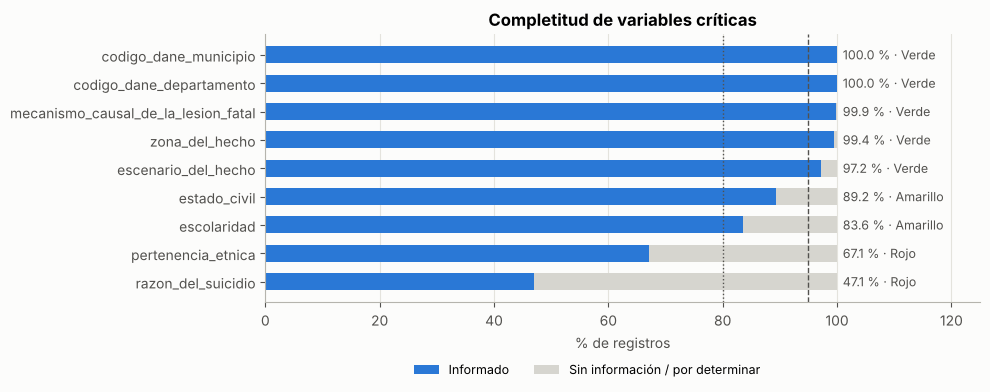

,% informado,% sin información,% nulo,% error,semáforo
dimension,,,,,
razon_del_suicidio,47.07,52.93,0.0,0.00,Rojo
pertenencia_etnica,67.09,32.91,0.0,0.00,Rojo
escolaridad,83.60,16.40,0.0,0.00,Amarillo
estado_civil,89.25,10.75,0.0,0.00,Amarillo
escenario_del_hecho,97.15,2.85,0.0,0.00,Verde
zona_del_hecho,99.39,0.61,0.0,0.00,Verde
mecanismo_causal_de_la_lesion_fatal,99.87,0.13,0.0,0.00,Verde
codigo_dane_departamento,99.98,0.02,0.0,0.00,Verde
codigo_dane_municipio,99.98,0.00,0.0,0.02,Verde


In [5]:
k3 = kpis[kpis["indicador"].eq("KPI3")].set_index("dimension")[["valor", "pct_sin_info", "pct_nulo", "pct_error", "estado"]]
k3 = k3.rename(columns={"valor": "% informado", "pct_sin_info": "% sin información", "pct_nulo": "% nulo",
                        "pct_error": "% error", "estado": "semáforo"}).sort_values("% informado")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(k3.index, k3["% informado"], color=AZUL, height=0.6, label="Informado")
ax.barh(k3.index, k3["% sin información"], left=k3["% informado"], color="#d6d5cf", height=0.6,
        label="Sin información / por determinar")
for y, (v, s) in enumerate(zip(k3["% informado"], k3["semáforo"])):
    ax.text(101, y, f"{v:.1f} % · {s}", va="center", fontsize=9, color="#52514e")
ax.axvline(U["kpi3_completitud_verde"], color="#52514e", ls="--", lw=1)
ax.axvline(U["kpi3_completitud_amarillo"], color="#52514e", ls=":", lw=1)
ax.set(xlim=(0, 125), xlabel="% de registros", title="Completitud de variables críticas")
ax.legend(loc="lower center", bbox_to_anchor=(0.45, -0.32), ncol=2, fontsize=9); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
k3

- **En rojo:** la **razón del suicidio** (47,1 % informada) y la **pertenencia étnica** (67,1 %). Cualquier conclusión sobre motivos o grupos étnicos se refiere solo a los casos en que Medicina Legal pudo documentar el dato, no al total.
- **En amarillo:** **escolaridad** (83,6 %) y **estado civil** (89,3 %).
- **En verde:** las variables geográficas, el mecanismo y la zona del hecho están por encima del 97 %.
- No hay nulos de sistema: todo el faltante viene como la categoría "Sin información".
- **Observación de calidad en escolaridad:** la fuente mezcla dos clasificaciones según el año, y en la nueva hay 2.336 casos en "Educación inicial y preescolar", un número alto para víctimas que en su mayoría son adultas. Se homologó en `escolaridad_agrupada`, pero esa categoría debe leerse con cautela; es un hallazgo para reportar a la fuente.

## 5. KPI 2 — Tasa de mortalidad por presunto suicidio

$$\text{Tasa} = \frac{\text{casos de presunto suicidio}}{\text{población proyectada DANE}} \times 100.000$$

- **Anual:** casos del año / población del año.
- **Quinquenal o decenal:** suma de casos / suma de poblaciones anuales (personas-año). Es la forma correcta de agregar varios años.
- **Tasa media anual:** promedio de las tasas anuales, **incluidos los años con 0 casos**. Es la métrica que usó el documento.
- Una tasa con **menos de 20 casos** se marca como **inestable**: un caso de más o de menos la mueve mucho.

### 5.1 Llave de cruce con el DANE

In [6]:
dim_edad = leer("dim_grupo_edad")
print("Departamentos:", len(dim_dep), "| Municipios DANE:", len(dim_mun), "| Grupos de edad:", len(dim_edad))
display(dim_edad[["grupo_edad", "edad_min", "edad_max", "menor_de_edad"]].set_index("grupo_edad").T)
pd.DataFrame({
    "Nivel": ["Nacional", "Departamental", "Departamental por sexo y edad", "Municipal (6 municipios foco)"],
    "Numerador (Medicina Legal)": ["todos los casos válidos", "codigo_dane_departamento + año",
                                   "+ sexo_de_la_victima + grupo_de_edad_quinquenal", "codigo_dane_municipio + año"],
    "Denominador (DANE)": ["suma de departamentos", "DP + AÑO (área Total)",
                           "DP + AÑO + sexo + edades simples agrupadas con dim_grupo_edad", "MPIO + AÑO (área Total)"],
}).style.hide(axis="index")

Departamentos: 33 | Municipios DANE: 1123 | Grupos de edad: 17


grupo_edad,(05 a 09),(10 a 14),(15 a 17),(18 a 19),(20 a 24),(25 a 29),(30 a 34),(35 a 39),(40 a 44),(45 a 49),(50 a 54),(55 a 59),(60 a 64),(65 a 69),(70 a 74),(75 a 79),(80 y más)
edad_min,5,10,15,18,20,25,30,35,40,45,50,55,60,65,70,75,80
edad_max,9,14,17,19,24,29,34,39,44,49,54,59,64,69,74,79,100
menor_de_edad,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Nivel,Numerador (Medicina Legal),Denominador (DANE)
Nacional,todos los casos válidos,suma de departamentos
Departamental,codigo_dane_departamento + año,DP + AÑO (área Total)
Departamental por sexo y edad,+ sexo_de_la_victima + grupo_de_edad_quinquenal,DP + AÑO + sexo + edades simples agrupadas con dim_grupo_edad
Municipal (6 municipios foco),codigo_dane_municipio + año,MPIO + AÑO (área Total)


Los códigos de Medicina Legal vienen sin cero a la izquierda (`5` = Antioquia); en silver se normalizan a 2 dígitos (departamento) y 5 dígitos (municipio), como los del DANE. Los grupos de Medicina Legal no son todos quinquenales (`15 a 17`, `18 a 19`), por eso la población se suma desde **edades simples**. El chequeo de denominadores (KR2) confirma que la población por sexo y edad suma exactamente el total departamental oficial.

### 5.2 Nivel nacional

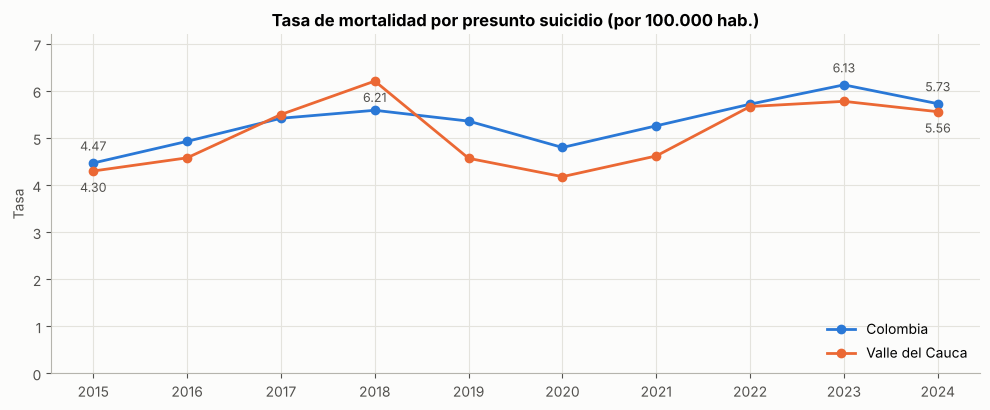

,Colombia casos,Colombia poblacion,Colombia tasa_100k,Valle casos,Valle poblacion,Valle tasa_100k
periodo,,,,,,
2015,2068,46313898,4.47,189,4397194,4.30
2016,2310,46830116,4.93,202,4414569,4.58
2017,2571,47419200,5.42,244,4432549,5.50
2018,2696,48258494,5.59,278,4475873,6.21
2019,2643,49266526,5.36,207,4533931,4.57
2020,2420,50390790,4.80,192,4598318,4.18
2021,2689,51115637,5.26,214,4636501,4.62
2022,2952,51643565,5.72,264,4658811,5.67
2023,3195,52117067,6.13,270,4673395,5.78


In [7]:
nac = tasa("Nacional").set_index("periodo")
valle = tasa("Departamento", FOCO).set_index("periodo")

fig, ax = plt.subplots()
ax.plot(nac.index, nac["tasa_100k"], marker="o", ms=6, color=AZUL, label="Colombia")
ax.plot(valle.index, valle["tasa_100k"], marker="o", ms=6, color=NARANJA, label="Valle del Cauca")
for serie, color, dy in [(nac, AZUL, 9), (valle, NARANJA, -15)]:   # Colombia arriba, Valle abajo
    for p in [serie.index[0], serie["tasa_100k"].idxmax(), serie.index[-1]]:
        ax.annotate(f"{serie.loc[p, 'tasa_100k']:.2f}", (p, serie.loc[p, "tasa_100k"]), xytext=(0, dy),
                    textcoords="offset points", ha="center", fontsize=9, color="#52514e")
ax.set(title="Tasa de mortalidad por presunto suicidio (por 100.000 hab.)", ylabel="Tasa", ylim=(0, 7.2))
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

tabla = nac[["casos", "poblacion", "tasa_100k"]].rename(columns=lambda c: f"Colombia {c}").join(
    valle[["casos", "poblacion", "tasa_100k"]].rename(columns=lambda c: f"Valle {c}"))
tabla

In [8]:
dec = tasa(tipo="decenio")
n_dec, v_dec = dec[dec["nivel"].eq("Nacional")].iloc[0], dec[dec["codigo"].eq(FOCO)].iloc[0]
print(f"Colombia 2015-2024: {fmt(n_dec['casos'])} casos, tasa {n_dec['tasa_100k']:.2f}; "
      f"tasa media anual {nac['tasa_100k'].mean():.2f}")
print(f"Valle    2015-2024: {fmt(v_dec['casos'])} casos, tasa {v_dec['tasa_100k']:.2f}; "
      f"tasa media anual {valle['tasa_100k'].mean():.2f}")
print(f"Variación de casos nacionales 2015 -> 2023: {(nac.loc['2023','casos']/nac.loc['2015','casos']-1)*100:.1f} %; "
      f"2015 -> 2024: {(nac.loc['2024','casos']/nac.loc['2015','casos']-1)*100:.1f} %")
print(f"Variación de la tasa nacional 2015 -> 2024: {(nac.loc['2024','tasa_100k']/nac.loc['2015','tasa_100k']-1)*100:.1f} %")

Colombia 2015-2024: 26.558 casos, tasa 5.35; tasa media anual 5.34
Valle    2015-2024: 2.321 casos, tasa 5.10; tasa media anual 5.10
Variación de casos nacionales 2015 -> 2023: 54.5 %; 2015 -> 2024: 45.7 %
Variación de la tasa nacional 2015 -> 2024: 28.2 %


- La tasa nacional sube de **4,47 (2015)** a un máximo de **6,13 (2023)** y baja a **5,73 en 2024**. 2020 es el único año con una caída marcada (4,80), coherente con el cambio en la dinámica social durante la pandemia.
- El **Valle del Cauca** está **por debajo de la tasa nacional en 8 de los 10 años** (5,10 frente a 5,35 en el decenio). Las excepciones son 2017 y sobre todo **2018**, cuando llegó a 6,21, su máximo del periodo.
- Los casos crecen más que la tasa (+45,7 % frente a +28,2 % entre 2015 y 2024) porque parte del aumento se explica por el crecimiento de la población; por eso se monitorea la tasa y no el conteo.

### 5.3 Por sexo y grupo de edad (Colombia y Valle del Cauca)

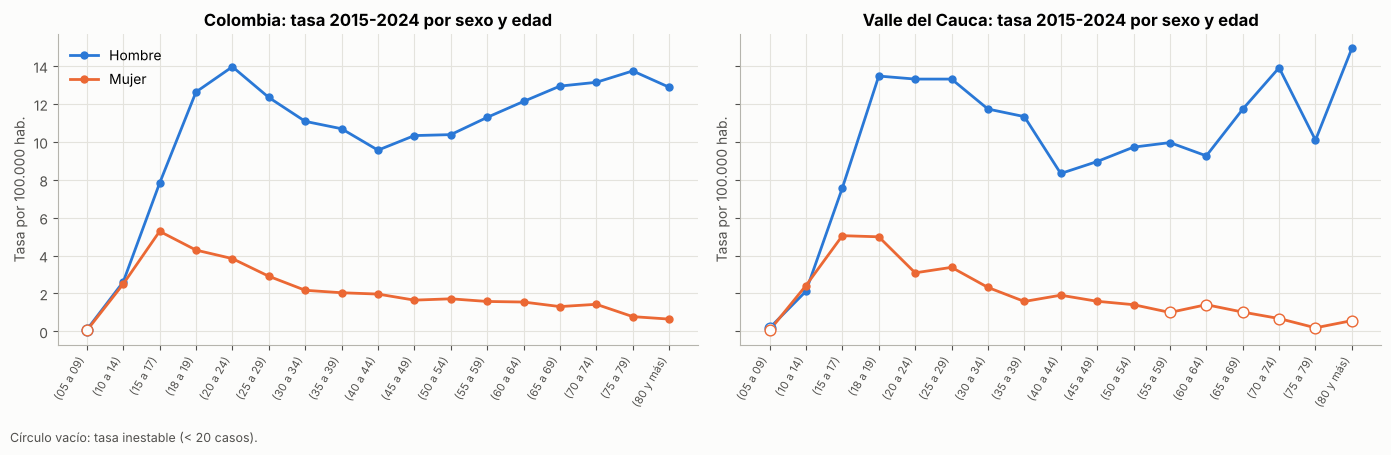

sexo,Hombre,Mujer,Total,Razón hombre:mujer (tasa)
territorio,,,,
Colombia,8.79,2.06,5.35,4.27
Valle del Cauca,8.66,1.86,5.10,4.66


In [9]:
dim_edad = dim_edad.sort_values("orden")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), sharey=True)
for ax, (cod, nombre) in zip(axes, [(None, "Colombia"), (FOCO, "Valle del Cauca")]):
    nivel = "Nacional" if cod is None else "Departamento"
    for sexo, color in [("Hombre", AZUL), ("Mujer", NARANJA)]:
        t = tasas[(tasas["nivel"] == nivel) & (tasas["tipo_periodo"] == "decenio") & (tasas["sexo"] == sexo)
                  & (tasas["grupo_edad"] != "Total") & ((tasas["codigo"] == cod) if cod else True)]
        t = t.set_index("grupo_edad").reindex(dim_edad["grupo_edad"])
        ax.plot(range(len(t)), t["tasa_100k"], marker="o", ms=5, color=color, label=sexo)
        inestables = t[~t["estable"].astype(bool)]
        ax.scatter([list(t.index).index(g) for g in inestables.index], inestables["tasa_100k"], s=60,
                   facecolors="#fcfcfb", edgecolors=color, zorder=3)
    ax.set_xticks(range(len(dim_edad))); ax.set_xticklabels(dim_edad["grupo_edad"], rotation=60, ha="right", fontsize=8)
    ax.set(title=f"{nombre}: tasa 2015-2024 por sexo y edad", ylabel="Tasa por 100.000 hab.")
axes[0].legend(); fig.text(0.01, -0.04, "Círculo vacío: tasa inestable (< 20 casos).", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

sexo = tasa(tipo="decenio").pipe(lambda d: tasas[(tasas["tipo_periodo"] == "decenio") & (tasas["grupo_edad"] == "Total")
                                                 & (tasas["nivel"].eq("Nacional") | tasas["codigo"].eq(FOCO))])
razon = sexo.pivot_table(index="territorio", columns="sexo", values="tasa_100k")
razon["Razón hombre:mujer (tasa)"] = (razon["Hombre"] / razon["Mujer"]).round(2)
razon

- La tasa en **hombres** es entre 4 y 5 veces la de **mujeres**, en el país y en el Valle.
- En **hombres** hay dos picos: uno en la juventud (**14,0 a los 20-24 años** en el país) y otro en las edades mayores (**13,7 a los 75-79**); en el Valle el más alto es el de **80 y más (14,9)**.
- En **mujeres** el pico está en la **adolescencia (5,3 a los 15-17 años)** y después la tasa baja de forma continua.
- Son inestables (menos de 20 casos) el grupo de 5-9 años en ambos niveles y, en el Valle, las mujeres de 55 años o más: esas tasas se leen como orden de magnitud, no como un valor preciso.

### 5.4 Nivel departamental

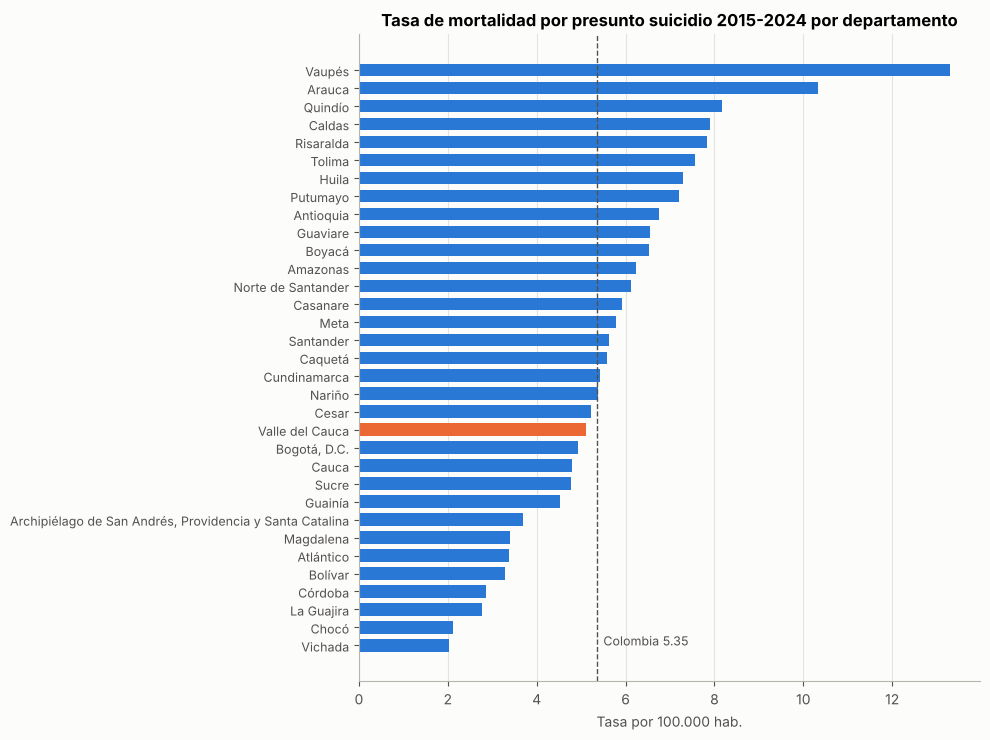

,codigo,territorio,region,casos,tasa_media_anual,anios_con_0_casos,tasa_2015_2024
1,97,Vaupés,Amazonia,55,13.01,2,13.31
2,81,Arauca,Orinoquia,272,10.34,0,10.32
3,63,Quindío,Andina,444,8.17,0,8.16
4,17,Caldas,Andina,804,7.89,0,7.91
5,66,Risaralda,Andina,753,7.81,0,7.83
6,73,Tolima,Andina,1021,7.56,0,7.57
7,41,Huila,Andina,823,7.30,0,7.30
8,86,Putumayo,Amazonia,258,7.19,0,7.21
9,05,Antioquia,Andina,4419,6.73,0,6.76
10,95,Guaviare,Amazonia,54,6.53,0,6.56


In [10]:
anual = tasa("Departamento")
resumen_dep = (anual.groupby(["codigo", "territorio", "region"])
               .agg(casos=("casos", "sum"), tasa_media_anual=("tasa_100k", "mean"), anios_con_0_casos=("casos", lambda c: int((c == 0).sum())))
               .reset_index())
resumen_dep = resumen_dep.merge(tasa("Departamento", tipo="decenio")[["codigo", "tasa_100k"]]
                                .rename(columns={"tasa_100k": "tasa_2015_2024"}), on="codigo")
resumen_dep = resumen_dep.sort_values("tasa_2015_2024", ascending=False).reset_index(drop=True)
resumen_dep.index += 1

fig, ax = plt.subplots(figsize=(10, 7.5))
r = resumen_dep.iloc[::-1]
colores = [NARANJA if c == FOCO else AZUL for c in r["codigo"]]
ax.barh(r["territorio"], r["tasa_2015_2024"], color=colores, height=0.7)
ax.axvline(n_dec["tasa_100k"], color="#52514e", ls="--", lw=1)
ax.text(n_dec["tasa_100k"] + 0.15, 0, f"Colombia {n_dec['tasa_100k']:.2f}", fontsize=9, color="#52514e")
ax.set(title="Tasa de mortalidad por presunto suicidio 2015-2024 por departamento", xlabel="Tasa por 100.000 hab.")
ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.show()
resumen_dep.round(2)

- Las tasas más altas están en **Vaupés (13,3)**, **Arauca (10,3)** y el **Eje Cafetero y el Tolima** (Quindío, Caldas, Risaralda, Tolima, entre 7,6 y 8,2).
- Vaupés tuvo **0 casos en 2015 y 2016** y entre 4 y 11 en los años siguientes: con una población de unos 40.000 habitantes, su tasa anual es inestable. Los años en 0 pueden reflejar **subregistro** más que ausencia de casos.
- El **Valle del Cauca (5,10)** queda en la mitad baja, por debajo del promedio nacional, aunque es el **tercer departamento con más casos** (2.321) por su tamaño.

### 5.5 Valle del Cauca y municipios foco

Tasa municipal completa para Cali, Palmira, Buenaventura, Jamundí, Tuluá y Buga. Como los municipios pequeños tienen pocos casos por año, la tasa se presenta por **quinquenio** y para el **decenio**; la anual queda en `gold_tasa_mortalidad`, marcada como estable o inestable.

casos                     tasa_100k                     anios con tasa estable
periodo             2015-2019 2015-2024 2020-2024 2015-2019 2015-2024 2020-2024                       
territorio                                                                                            
Tuluá                    74.0     134.0      60.0      7.02      6.19      5.41                1 de 10
Guadalajara de Buga      36.0      80.0      44.0      5.66      6.18      6.69                0 de 10
Palmira                  89.0     188.0      99.0      5.12      5.23      5.32                4 de 10
Cali                    477.0    1010.0     533.0      4.31      4.50      4.68               10 de 10
Buenaventura             51.0     119.0      68.0      3.33      3.79      4.22                1 de 10
Jamundí                  25.0      61.0      36.0      3.18      3.60      3.97                0 de 10

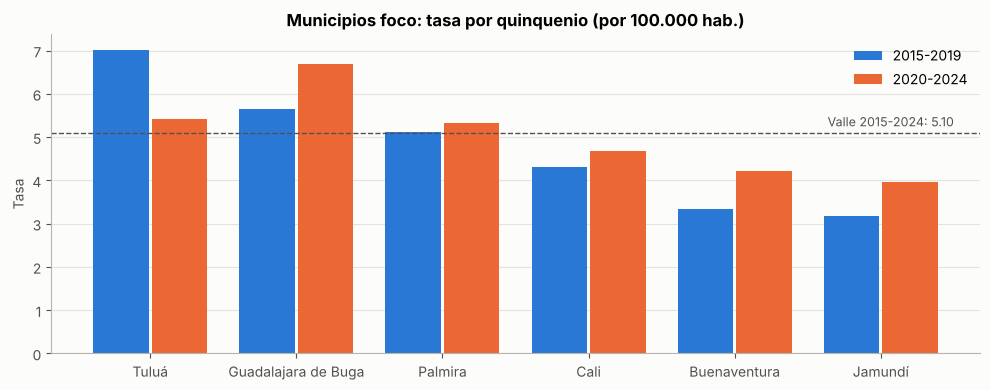

In [11]:
mun = tasas[(tasas["nivel"] == "Municipio")]
tabla_mun = (mun[mun["tipo_periodo"] != "anual"].pivot_table(index="territorio", columns="periodo", values=["casos", "tasa_100k"])
             .sort_values(("tasa_100k", "2015-2024"), ascending=False))
anual_mun = mun[mun["tipo_periodo"] == "anual"]
estables = anual_mun.groupby("territorio")["estable"].apply(lambda s: f"{int(s.astype(bool).sum())} de {len(s)}")
tabla_mun[("anios con tasa estable", "")] = estables
display(tabla_mun)

orden = tabla_mun.index.tolist()
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(orden)); ancho = 0.38
for i, (per, color) in enumerate([("2015-2019", AZUL), ("2020-2024", NARANJA)]):
    vals = mun[mun["periodo"] == per].set_index("territorio").loc[orden, "tasa_100k"]
    ax.bar([xi + (i - 0.5) * (ancho + 0.02) for xi in x], vals, width=ancho, color=color, label=per)
ax.axhline(v_dec["tasa_100k"], color="#52514e", ls="--", lw=1)
ax.text(len(orden) - 0.5, v_dec["tasa_100k"] + 0.15, f"Valle 2015-2024: {v_dec['tasa_100k']:.2f}", ha="right", fontsize=9, color="#52514e")
ax.set_xticks(list(x)); ax.set_xticklabels(orden)
ax.set(title="Municipios foco: tasa por quinquenio (por 100.000 hab.)", ylabel="Tasa"); ax.legend()
ax.grid(axis="x", visible=False); plt.tight_layout(); plt.show()

- **Tuluá (6,19)** y **Buga (6,18)** tienen las tasas más altas de los seis, por encima del Valle (5,10) y del país (5,35). Tuluá bajó entre quinquenios (7,02 → 5,41); Buga subió (5,66 → 6,69).
- **Palmira (5,23)** está en el nivel del departamento.
- **Cali (4,50)** concentra el 43 % de los casos del Valle (1.010), pero su tasa está por debajo del promedio departamental.
- **Buenaventura (3,79)** y **Jamundí (3,60)** tienen las tasas más bajas, ambas en aumento entre quinquenios.
- Las seis tasas decenales son **estables** (≥ 20 casos). En cambio, la tasa anual solo es estable todos los años en **Cali**; Palmira lo es en 4 de 10 años y los demás en 1 o ninguno. Por eso, para esos municipios se lee el quinquenio o el decenio.

### 5.6 Otros municipios del Valle (solo conteos agregados)

Para el resto de municipios no se calcula tasa: con tan pocos casos sería inestable y podría permitir identificar personas. Se publica solo el conteo del decenio, y los municipios con menos de 5 casos aparecen como suprimidos.

In [12]:
otros = tablero[(tablero["nivel"] == "Municipio") & (tablero["variable"] == "total") & (tablero["periodo"] == "2015-2024")
                & ~tablero["codigo"].isin(config["scope"]["municipios_foco"])]
otros = otros.sort_values("casos", ascending=False, na_position="last")[["territorio", "casos", "suprimido"]]
otros["casos"] = otros["casos"].map(lambda v: "< 5" if pd.isna(v) else fmt(v))
print(f"{len(otros)} municipios; {int(otros['suprimido'].sum())} con menos de {K} casos en el decenio (suprimidos)")
otros.reset_index(drop=True)

36 municipios; 3 con menos de 5 casos en el decenio (suprimidos)


,territorio,casos,suprimido
0,Cartago,98,False
1,Yumbo,72,False
2,Candelaria,60,False
3,El Cerrito,41,False
4,Dagua,33,False
5,Sevilla,29,False
6,Caicedonia,29,False
7,Florida,29,False
8,Guacarí,26,False
9,Roldanillo,24,False


## 6. Preguntas de negocio

### P1. ¿Qué departamentos y municipios tienen las tasas de mortalidad por presunto suicidio más altas de forma sostenida?

Se considera **sostenida** una tasa que supera la nacional en al menos 8 de los 10 años.

In [13]:
comp = anual.merge(nac[["tasa_100k"]].rename(columns={"tasa_100k": "tasa_nacional"}), left_on="periodo", right_index=True)
comp["por_encima"] = comp["tasa_100k"] > comp["tasa_nacional"]
sostenida = (comp.groupby(["territorio", "region"]).agg(anios_por_encima=("por_encima", "sum"),
                                                       anios_estables=("estable", "sum"))
             .reset_index().merge(resumen_dep[["territorio", "tasa_2015_2024"]], on="territorio")
             .query("anios_por_encima >= 8").sort_values("tasa_2015_2024", ascending=False).reset_index(drop=True))
sostenida

,territorio,region,anios_por_encima,anios_estables,tasa_2015_2024
0,Vaupés,Amazonia,8,0,13.31
1,Arauca,Orinoquia,10,10,10.32
2,Quindío,Andina,10,10,8.16
3,Caldas,Andina,10,10,7.91
4,Risaralda,Andina,10,10,7.83
5,Tolima,Andina,9,10,7.57
6,Huila,Andina,10,10,7.30
7,Putumayo,Amazonia,9,9,7.21
8,Antioquia,Andina,10,10,6.76
9,Boyacá,Andina,10,10,6.52


**Once departamentos** superan la tasa nacional en al menos 8 de los 10 años:
- **Ocho son andinos:** el Eje Cafetero (Quindío, Caldas, Risaralda), Tolima, Huila, Antioquia, Boyacá y Norte de Santander.
- **Uno es de la Orinoquía:** Arauca, por encima todos los años.
- **Dos son de la Amazonía:** Putumayo y Vaupés. Vaupés tiene la tasa más alta, pero **ninguno** de sus años es estable (menos de 20 casos por año), así que su posición es la menos robusta de la lista.

En el Valle, entre los municipios foco, **Tuluá y Buga** están por encima del promedio nacional en el decenio, como se vio en la sección 5.5.

### P2. ¿Cómo ha evolucionado la distribución de los casos por ciclo vital y sexo?

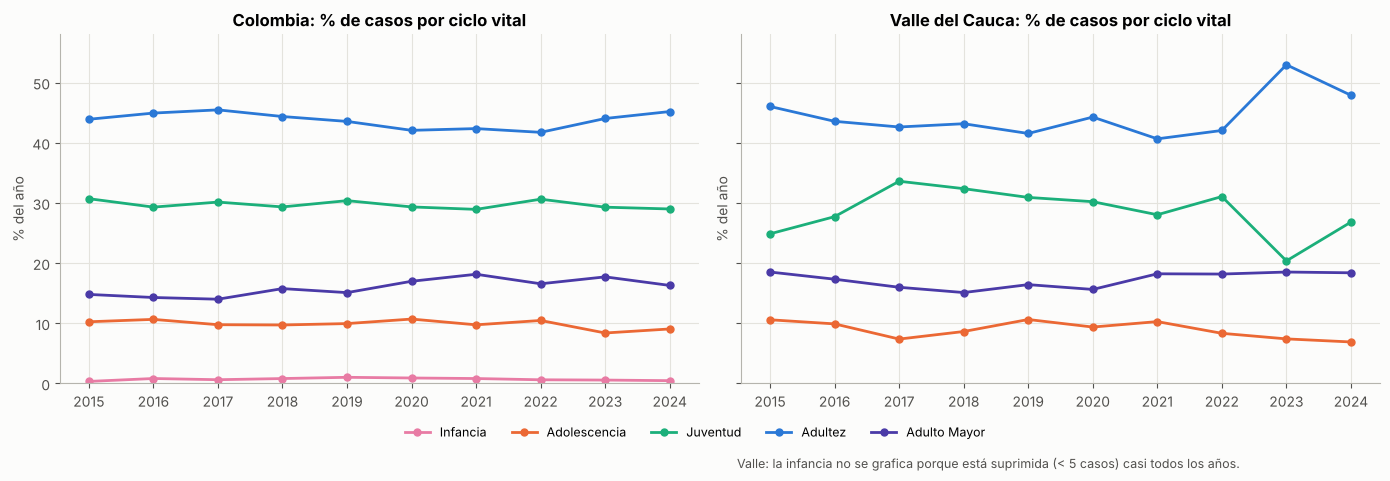

% de casos en hombres por año


periodo,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Colombia,80.0,81.7,81.5,82.3,79.6,80.9,81.0,79.7,77.5,80.3
Valle,77.2,78.2,81.6,84.5,80.7,83.9,78.5,82.6,79.3,80.8


In [14]:
def distribucion(variable, codigo):
    d = tablero[(tablero["variable"] == variable) & (tablero["codigo"] == codigo) & (tablero["periodo"].str.len() == 4)]
    p = d.pivot_table(index="periodo", columns="categoria", values="casos", aggfunc="first", dropna=False)
    total = tablero[(tablero["variable"] == "total") & (tablero["codigo"] == codigo)].set_index("periodo")["casos"]
    return p.div(total.reindex(p.index), axis=0) * 100   # celdas suprimidas quedan vacias, no en 0

ORDEN_CICLO = ["(06 a 11) Infancia", "(12 a 17) Adolescencia", "(18 a 28) Juventud", "(29 a 59) Adultez", "(Más de 60) Adulto Mayor"]
COLORES_CICLO = ["#e87ba4", NARANJA, AQUA, AZUL, "#4a3aa7"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), sharey=True)
for ax, (cod, nombre) in zip(axes, [("00", "Colombia"), (FOCO, "Valle del Cauca")]):
    p = distribucion("ciclo_vital", cod).reindex(columns=ORDEN_CICLO)
    for c, color in zip(ORDEN_CICLO, COLORES_CICLO):
        if c in p and p[c].notna().all():
            ax.plot(p.index, p[c], marker="o", ms=5, color=color, label=c.split(") ")[1])
    ax.set(title=f"{nombre}: % de casos por ciclo vital", ylabel="% del año", ylim=(0, 58))
manijas, etiquetas = axes[0].get_legend_handles_labels()
fig.legend(manijas, etiquetas, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.text(0.53, -0.1, "Valle: la infancia no se grafica porque está suprimida (< 5 casos) casi todos los años.",
         fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

hombres = pd.DataFrame({n: distribucion("sexo_de_la_victima", c)["Hombre"] for c, n in [("00", "Colombia"), (FOCO, "Valle")]})
print("% de casos en hombres por año"); hombres.round(1).T

- La **adultez (29-59 años)** concentra entre el 42 % y el 46 % de los casos cada año en el país, y la **juventud (18-28)** entre el 29 % y el 31 %.
- La participación de los **adultos mayores** sube de 14-15 % (2015-2017) a 16-18 % (2020-2024).
- En el Valle la distribución varía más de un año a otro; en 2023 la adultez llegó al 53 % de los casos. La **infancia** queda suprimida casi todos los años (menos de 5 casos), por eso esa serie no se grafica.
- Los **hombres** son alrededor del **80 %** de los casos todos los años (77,5 % a 82,3 % en el país). En el Valle oscila más, entre 77 % y 85 %.

### P3. ¿Qué razones se reportan con mayor frecuencia en los distintos grupos poblacionales?

Solo sobre los casos con razón **informada** (47,1 %, KPI 3 en rojo): los porcentajes describen los casos documentados, no el total.

In [15]:
inf = casos[casos["razon_agrupada"] != "Sin informacion"]
def top_razones(grupo, k=3):
    t = (inf.groupby(grupo)["razon_agrupada"].value_counts(normalize=True).mul(100).round(1)
         .groupby(level=0).head(k).rename("%").reset_index())
    n = inf.groupby(grupo).size().rename("casos informados")
    return t.merge(n, left_on=grupo, right_index=True)

print(f"Casos con razón informada: {fmt(len(inf))} de {fmt(len(casos))} ({len(inf)/len(casos)*100:.1f} %)")
display(top_razones("ciclo_vital").pivot_table(index="ciclo_vital", columns="razon_agrupada", values="%").fillna("—"))
top_razones("sexo_de_la_victima").pivot_table(index="sexo_de_la_victima", columns="razon_agrupada", values="%").fillna("—")

Casos con razón informada: 12.500 de 26.558 (47.1 %)


razon_agrupada,Conflicto de pareja o expareja,Desamor,Economicas,Enfermedad fisica o mental,Enfermedad mental,Muerte de un familiar o amigo,Otras
ciclo_vital,,,,,,,
(06 a 11) Infancia,—,9.4,—,—,—,7.5,71.7
(12 a 17) Adolescencia,13.9,22.1,—,—,—,—,32.6
(18 a 28) Juventud,26.5,20.9,—,—,13.9,—,—
(29 a 59) Adultez,25.9,—,17.2,16.4,—,—,—
(Más de 60) Adulto Mayor,—,—,16.3,29.6,19.3,—,—


razon_agrupada,Conflicto de pareja o expareja,Economicas,Enfermedad fisica o mental,Enfermedad mental
sexo_de_la_victima,,,,
Hombre,21.8,14.6,16.2,—
Mujer,21.3,—,17.7,20.7


In [16]:
inf_valle = inf[inf["codigo_dane_departamento"] == FOCO]
comparacion = pd.DataFrame({"Colombia (%)": inf["razon_agrupada"].value_counts(normalize=True) * 100,
                            "Valle del Cauca (%)": inf_valle["razon_agrupada"].value_counts(normalize=True) * 100}).round(1)
print(f"Valle: {fmt(len(inf_valle))} casos con razón informada de {fmt((casos['codigo_dane_departamento'] == FOCO).sum())}")
comparacion.sort_values("Colombia (%)", ascending=False)

Valle: 959 casos con razón informada de 2.321


,Colombia (%),Valle del Cauca (%)
razon_agrupada,,
Conflicto de pareja o expareja,21.7,22.3
Enfermedad fisica o mental,16.5,18.7
Enfermedad mental,14.4,12.2
Desamor,13.9,10.3
Economicas,13.1,14.9
Otras,9.1,9.4
Abuso de sustancias y alcohol,3.5,3.0
Enfermedad fisica,3.4,3.2
Muerte de un familiar o amigo,3.1,4.9


- En **adolescentes**, el grupo más grande es "Otras" (32,6 %), que reúne motivos escolares, bullying, maltrato y similares; le siguen el **desamor** (22,1 %) y el conflicto de pareja (13,9 %).
- En **jóvenes** predominan los motivos **relacionales**: conflicto de pareja (26,5 %) y desamor (20,9 %).
- En la **adultez**, el conflicto de pareja (25,9 %) va seguido de las **razones económicas** (17,2 %).
- En el **adulto mayor** dominan las **enfermedades**: física o mental (29,6 %) y mental (19,3 %).

Ese gradiente coincide con el enfoque del ciclo vital del documento.

Por sexo, el conflicto de pareja es el primer motivo en ambos (≈ 21-22 %). En hombres aparecen las **económicas** entre los tres primeros; en mujeres, la **enfermedad mental** (20,7 %).

El Valle sigue el patrón nacional, con algo más de peso de la enfermedad física o mental (18,7 %) y lo económico (14,9 %), y menos del desamor (10,3 %).

### P4. ¿Cómo se distribuyen los casos por escolaridad, pertenencia étnica y estado civil, y qué diferencias hay entre regiones?

Celdas con menos de 5 casos suprimidas. Porcentajes sobre los casos con el dato informado de cada variable.

In [17]:
def por_region(variable):
    d = casos[(casos["region"] != "Sin informacion") & (casos[variable] != "Sin informacion")
              & (casos[variable] != "Sin información")]
    t = pd.crosstab(d[variable], d["region"])
    pct = (t / t.sum() * 100).round(1)
    return pct.where(t >= K).astype(object).where(t >= K, "< 5 casos")

for var, titulo in [("escolaridad_agrupada", "Escolaridad"), ("pertenencia_etnica", "Pertenencia étnica"),
                    ("estado_civil", "Estado civil")]:
    print(f"\n{titulo} (% por región, sobre casos informados)")
    display(por_region(var))


Escolaridad (% por región, sobre casos informados)


region,Amazonia,Andina,Caribe,Orinoquia,Pacifica
escolaridad_agrupada,,,,,
Basica primaria,43.7,30.4,32.3,37.3,32.5
Basica secundaria,15.2,20.7,19.4,15.1,20.4
Media,19.5,23.4,19.5,19.0,22.9
Posgrado,< 5 casos,0.3,0.2,< 5 casos,< 5 casos
Preescolar,14.4,12.4,13.6,16.1,13.4
Sin escolaridad,3.4,3.0,7.6,5.6,2.4
Tecnica o tecnologica,3.2,9.3,7.1,6.7,8.1
Universitaria,< 5 casos,0.5,0.3,< 5 casos,0.2



Pertenencia étnica (% por región, sobre casos informados)


region,Amazonia,Andina,Caribe,Orinoquia,Pacifica
pertenencia_etnica,,,,,
Indígena,19.3,1.1,1.8,5.6,5.3
Negro/Afrodescendiente,1.3,0.4,0.3,< 5 casos,5.7
Raizal,< 5 casos,< 5 casos,< 5 casos,< 5 casos,< 5 casos
Sin Pertenencia Étnica,79.2,98.6,97.9,94.1,89.0



Estado civil (% por región, sobre casos informados)


region,Amazonia,Andina,Caribe,Orinoquia,Pacifica
estado_civil,,,,,
Casado(a),6.5,15.8,12.4,9.7,12.4
No aplica,< 5 casos,0.1,< 5 casos,< 5 casos,0.2
"Separado(a), divorciado(a)",4.3,5.4,4.1,5.0,4.4
Soltero(a),56.3,54.3,45.5,51.9,54.1
Unión libre,31.4,22.4,35.2,31.6,26.8
Viudo(a),1.4,2.1,2.7,1.6,2.0


- **Escolaridad:** predomina la básica primaria en todas las regiones (30 % a 44 %; la más alta en la Amazonía). La educación técnica o tecnológica pesa más en la región Andina (9,3 %), y la "sin escolaridad" en el **Caribe (7,6 %)** y la Orinoquía (5,6 %). El 12-16 % en "Preescolar" en todas las regiones confirma la observación de calidad del KPI 3.
- **Pertenencia étnica:** los casos de personas **indígenas** se concentran en la **Amazonía**, donde son una proporción mucho mayor que en el resto del país; los de población **negra o afrodescendiente**, en la región **Pacífica**. Esto refleja en parte la composición de la población de cada región: compararlo con tasas requeriría denominadores por etnia, que el DANE no publica en esta serie.
- **Estado civil:** la soltería y la unión libre suman entre el 77 % (Andina) y el 88 % (Amazonía) de los casos. La unión libre pesa más en el **Caribe (35,2 %)**, la Orinoquía y la Amazonía (≈ 31 %), y el matrimonio en la región Andina (15,8 %).

## 7. Gobierno y privacidad del dato

Aunque la fuente es pública, el pipeline aplica tres controles:

In [18]:
from src.transform.gold_data import COLUMNAS_EXCLUIDAS
pd.DataFrame({
    "Control": ["Minimización", "Agregación mínima", "Estabilidad", "Control de acceso"],
    "Regla": [f"Se excluyen de gold {len(COLUMNAS_EXCLUIDAS)} variables que no se usan: " + ", ".join(COLUMNAS_EXCLUIDAS),
              f"El tablero solo recibe conteos agregados; celdas de 1 a {K - 1} casos se suprimen",
              f"Tasas con menos de {U['tasa_min_casos_estable']} casos se marcan inestables; tasa municipal solo en 6 municipios foco",
              "PostgreSQL: rol_tablero (solo agregados) y rol_analista (detalle minimizado), sql/roles_postgres.sql"],
}).style.hide(axis="index")

Control,Regla
Minimización,"Se excluyen de gold 10 variables que no se usan: orientacion_sexual, identidad_de_genero, transgenero, pueblo_indigena, ancestro_racial, pertenencia_grupal, pais_de_nacimiento, localidad_del_hecho, diagnostico_topografico_de_la_lesion_fatal, rango_de_hora_del_hecho_x_3_horas"
Agregación mínima,El tablero solo recibe conteos agregados; celdas de 1 a 4 casos se suprimen
Estabilidad,Tasas con menos de 20 casos se marcan inestables; tasa municipal solo en 6 municipios foco
Control de acceso,"PostgreSQL: rol_tablero (solo agregados) y rol_analista (detalle minimizado), sql/roles_postgres.sql"


In [19]:
sup = tablero.groupby("nivel")["suprimido"].agg(celdas="size", suprimidas="sum")
sup["% suprimidas"] = (sup["suprimidas"] / sup["celdas"] * 100).round(1)
sup

,celdas,suprimidas,% suprimidas
nivel,,,
Departamento,16012,6211,38.8
Municipio,7955,6310,79.3
Nacional,661,27,4.1


- La supresión es mucho mayor a nivel municipal (79 % de las celdas), como se espera: ahí es donde un conteo pequeño podría permitir identificar a alguien. A nivel nacional solo se suprime el 4 %, sobre todo en categorías poco frecuentes de un solo año.
- **Límite conocido:** se aplica supresión primaria (celdas de menos de 5 casos), no supresión complementaria. Si un tablero muestra el total y todas las demás categorías de una misma tabla, un valor suprimido podría deducirse por resta. Por eso el tablero no debe mostrar en una misma vista el total y el desglose completo de un municipio pequeño.
- El `.env` con el token está en el repositorio para que el profesor pueda ejecutar el pipeline. Después de la calificación conviene **regenerar el token** en datos.gov.co.

## 8. Correcciones de KPI

Al recalcular todo desde gold aparecieron cifras del documento y del notebook de conclusiones que no cuadraban. Esta es la versión corregida y la causa de cada diferencia.

In [20]:
vaupes = anual[anual["territorio"] == "Vaupés"]
arauca = anual[anual["territorio"] == "Arauca"]

# Metodo del notebook de conclusiones: promedio de la tasa pegada a cada caso (pondera por numero de casos)
por_caso = casos.merge(anual[["codigo", "periodo", "tasa_100k"]].assign(periodo=lambda d: d["periodo"].astype(int)),
                       left_on=["codigo_dane_departamento", "ano_del_hecho"], right_on=["codigo", "periodo"])
por_caso = por_caso.groupby("departamento_del_hecho_dane")["tasa_100k"].mean()

pg = casos[casos["tipo_mecanismo"] != "Por determinar"].groupby("sexo_de_la_victima")["es_violento"].mean() * 100
pg_con = casos.groupby("sexo_de_la_victima")["es_violento"].mean() * 100

top8 = ["Antioquia", "Bogotá, D.C.", "Valle del Cauca", "Cundinamarca", "Santander", "Tolima", "Arauca", "Vaupés"]
resto = casos[~casos["departamento_del_hecho_dane"].isin(top8) & (casos["codigo_dane_departamento"] != "Sin informacion")]
n_resto_dep = resto["departamento_del_hecho_dane"].nunique()

correcciones = pd.DataFrame([
    ["Tasa media anual Vaupés", "16,26 (documento) / 17,77 (conclusiones)",
     f"{vaupes['tasa_100k'].mean():.2f} (media anual) · {resumen_dep.set_index('territorio').loc['Vaupés','tasa_2015_2024']:.2f} (decenio)",
     f"El documento excluyó los años con 0 casos (media sin ceros = {vaupes.loc[vaupes['casos']>0,'tasa_100k'].mean():.2f}); "
     f"conclusiones promedió la tasa de cada caso ({por_caso['Vaupés']:.2f}), que pondera más los años con más casos"],
    ["Tasa media anual Arauca", "10,34 (documento) / 10,66 (conclusiones)", f"{arauca['tasa_100k'].mean():.2f}",
     f"El documento es correcto; conclusiones usó el promedio por caso ({por_caso['Arauca']:.2f})"],
    ["Top 5 departamentos (conclusiones)", "Vaupés, Arauca, Quindío 8,36, Caldas 8,04, Guaviare 8,02",
     ", ".join(f"{r.territorio} {r.tasa_media_anual:.2f}" for r in resumen_dep.sort_values("tasa_media_anual", ascending=False).head(5).itertuples()),
     "Mismo sesgo del promedio por caso; Guaviare sale del top 5 y entra Risaralda"],
    ["Paradoja de género: % mecanismo violento", "86,7 / 73,2 (documento) · 86,6 / 73,0 (conclusiones)",
     f"{pg['Hombre']:.1f} % hombres / {pg['Mujer']:.1f} % mujeres",
     f"Ambas cifras son correctas con distinto denominador: conclusiones incluyó los 35 'Por determinar' "
     f"({pg_con['Hombre']:.1f} / {pg_con['Mujer']:.1f}). Se adopta el criterio del documento (excluirlos), igual que en la prueba chi-cuadrado"],
    ["Razón agrupada 'Otras' (gold)", "6.737 casos", f"{fmt((casos['razon_agrupada']=='Otras').sum())} casos",
     "Las claves no coincidían con la escritura real: conflicto de pareja, enfermedad física o mental, abuso de sustancias "
     "y muerte de familiar caían en 'Otras'. Corregido; coincide con la Tabla 8 del documento"],
    ["Tabla 3: 'Resto de departamentos'", "21 departamentos, 37,5 %",
     f"{n_resto_dep} departamentos, {fmt(len(resto))} casos, {len(resto)/len(casos)*100:.1f} %",
     "El conteo de casos era correcto (11.814), pero el número de departamentos y el porcentaje no"],
    ["Tabla 4: total de la tabla sexo × mecanismo", "26.558", fmt((casos["tipo_mecanismo"] != "Por determinar").sum()),
     "La tabla excluye los 35 casos 'Por determinar', así que su total es 26.523"],
    ["Término de la pregunta 1", "Tasa de incidencia", "Tasa de mortalidad por presunto suicidio",
     "Retroalimentación del profesor: son defunciones, no casos nuevos de una enfermedad"],
    ["KR1 y KR2", "100 % de carga y 100 % de limpieza", "Umbrales de la sección 2",
     "Retroalimentación del profesor: los datos reales pueden traer registros inválidos que se rechazan y documentan"],
], columns=["Indicador", "Valor anterior", "Valor corregido", "Causa"])
correcciones.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"})

Indicador,Valor anterior,Valor corregido,Causa
Tasa media anual Vaupés,"16,26 (documento) / 17,77 (conclusiones)",13.01 (media anual) · 13.31 (decenio),"El documento excluyó los años con 0 casos (media sin ceros = 16.26); conclusiones promedió la tasa de cada caso (17.77), que pondera más los años con más casos"
Tasa media anual Arauca,"10,34 (documento) / 10,66 (conclusiones)",10.34,El documento es correcto; conclusiones usó el promedio por caso (10.66)
Top 5 departamentos (conclusiones),"Vaupés, Arauca, Quindío 8,36, Caldas 8,04, Guaviare 8,02","Vaupés 13.01, Arauca 10.34, Quindío 8.17, Caldas 7.89, Risaralda 7.81",Mismo sesgo del promedio por caso; Guaviare sale del top 5 y entra Risaralda
Paradoja de género: % mecanismo violento,"86,7 / 73,2 (documento) · 86,6 / 73,0 (conclusiones)",86.7 % hombres / 73.2 % mujeres,"Ambas cifras son correctas con distinto denominador: conclusiones incluyó los 35 'Por determinar' (86.6 / 73.0). Se adopta el criterio del documento (excluirlos), igual que en la prueba chi-cuadrado"
Razón agrupada 'Otras' (gold),6.737 casos,1.137 casos,"Las claves no coincidían con la escritura real: conflicto de pareja, enfermedad física o mental, abuso de sustancias y muerte de familiar caían en 'Otras'. Corregido; coincide con la Tabla 8 del documento"
Tabla 3: 'Resto de departamentos',"21 departamentos, 37,5 %","25 departamentos, 11.814 casos, 44.5 %","El conteo de casos era correcto (11.814), pero el número de departamentos y el porcentaje no"
Tabla 4: total de la tabla sexo × mecanismo,26.558,26.523,"La tabla excluye los 35 casos 'Por determinar', así que su total es 26.523"
Término de la pregunta 1,Tasa de incidencia,Tasa de mortalidad por presunto suicidio,"Retroalimentación del profesor: son defunciones, no casos nuevos de una enfermedad"
KR1 y KR2,100 % de carga y 100 % de limpieza,Umbrales de la sección 2,Retroalimentación del profesor: los datos reales pueden traer registros inválidos que se rechazan y documentan


**Criterio adoptado para la tasa departamental:** se reportan dos medidas, cada una con su uso.
- **Tasa del decenio** (casos 2015-2024 / personas-año): es el resumen principal del periodo.
- **Tasa media anual** (promedio de las 10 tasas anuales, con los años en 0): se usa en el análisis inferencial, por ejemplo en el Kruskal-Wallis por región.

Ninguna de las dos debe excluir los años sin casos ni promediarse por caso.

## 9. Conclusiones

1. El pipeline **cumple los KR reformulados**: no se pierde ningún registro, el 100 % pasa las reglas obligatorias, no quedan variantes de escritura en gold y el 99,985 % de los casos cruza con la población del DANE.
2. La **tasa de mortalidad por presunto suicidio** en Colombia subió de 4,47 a 5,73 por 100.000 hab. entre 2015 y 2024 (máximo de 6,13 en 2023). El **Valle del Cauca** está por debajo del promedio nacional (5,10 frente a 5,35).
3. Dentro del Valle, **Tuluá y Buga** tienen las tasas más altas de los municipios foco (≈ 6,2). Cali concentra los casos, pero no la tasa.
4. La **razón del suicidio** y la **pertenencia étnica** tienen completitud baja (KPI 3 en rojo): los análisis de motivos se refieren solo a los casos documentados.
5. Al recalcular desde gold se corrigieron **nueve cifras** del documento, de las conclusiones y del Avance 1. La más importante es la tasa de Vaupés, que pasa de 16-18 a 13.